<a href="https://colab.research.google.com/github/nurfnick/Operations_Research/blob/main/ClassWork/exam2Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exam 2 Review

## Linear Programming Example

Wild west produces two types of cowboy hats.  Type A requires twice as much labor time as type B.  If all the labour time is dedicated to type B, the company can produce a total of 400 type B hats.  The market limit for hats is 150 and 200 for type A and B respecitively.  The profit for type A is \$ 8 and the profit for type B is \$ 5.  Determine the number of hats of each type that maximizes profit.

1. State Objective Function: Maximize Profit
$$
z = 8A + 5B
$$
2. State constraints
$$
\left\{
\begin{array}{l}
A\leq 150\\
B\leq 200\\
2A+B\leq 400\\
A,B\geq 0
\end{array}
  \right.
$$
3. Graph Feasible Region

See Below

4. Find corner points (use Gauss-Jordan for one)

G-J was done on board, know how to do it though!

$(0,0)$, $(150,0)$, $(0,200)$, $(150,100)$, $(100,200)$

5. Optimize

$(0,0,0)$,

$(150,0,8*150 = 1200)$,

$(0,200, 5*200 = 1000)$,

$(150,100, 8*150 +5 *100 = 1700)$,

$(100,200, 8*100 + 5*200 = 1800)$ MAX PROFIT!!!


6. State with Slack Variables

$$
\left\{
\begin{array}{l}
A + s_1 =  150\\
B + s_2 =  200\\
2A+B + s_3 = 400\\
A,B, s_1, s_2, s_3\geq 0
\end{array}
  \right.
$$
7. Create Tableau

$$
\left[
\begin{array}{ccccccc}
z&A&B&s_1&s_2&s_3&\#\\
0&1&0&1&0&0&150\\
0&0&1&0&1&0&200\\
0&2&1&0&0&1&400\\
1&-8&-5&0&0&0&0
\end{array}
  \right]
$$

8. Find position of first pivot in tableau

The biggest negative in the bottom row is A with -8 then we check where we have the minimum positive ratio of the constant and the coeffiecent.  We get 150/1 = 150 and 400/2 = 200 here we pick the minimum!  So row 1 is our choice!

9. Do this and read values from tableau

We need to do $-2R_1 + R_3 \to R_3$ and $8R_1 +R_4 \to R_4$

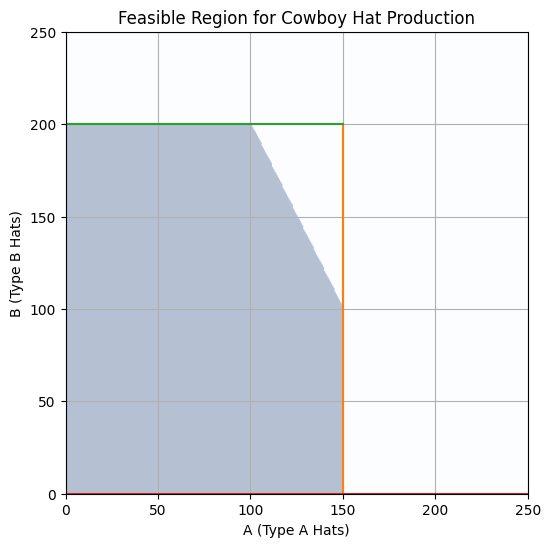

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Define the inequalities
# A <= 150
# B <= 200
# 2A + B <= 400
# A >= 0
# B >= 0

# Create a grid of points
A = np.linspace(0, 250, 400)
B = np.linspace(0, 450, 400)
A, B = np.meshgrid(A, B)

# Apply the inequalities
ineq1 = A <= 150
ineq2 = B <= 200
ineq3 = 2*A + B <= 400
ineq4 = A >= 0
ineq5 = B >= 0

# Combine the inequalities to find the feasible region
feasible_region = ineq1 & ineq2 & ineq3 & ineq4 & ineq5

# Plot the feasible region
plt.figure(figsize=(8, 6))
plt.imshow(feasible_region, extent=(0, 250, 0, 450), origin='lower', cmap='Blues', alpha=0.3)

# Plot the boundary lines
plt.plot(np.linspace(0, 150, 100), np.full(100, 400 - 2*0), label='2A + B = 400') # Plotting the boundary line 2A + B = 400
plt.plot(np.full(100, 150), np.linspace(0, 200, 100), label='A = 150')
plt.plot(np.linspace(0, 150, 100), np.full(100, 200), label='B = 200')
plt.plot(np.linspace(0, 250, 100), np.full(100, 0), label='B = 0')
plt.plot(np.full(100, 0), np.linspace(0, 450, 100), label='A = 0')

# Set plot limits and labels
plt.xlim(0, 250)
plt.ylim(0, 250)
plt.xlabel('A (Type A Hats)')
plt.ylabel('B (Type B Hats)')
plt.title('Feasible Region for Cowboy Hat Production')
#plt.legend()
plt.grid(True)
plt.show()

In [6]:
import numpy as np

# Define the tableau as a NumPy array
tableau = np.array([
    [0, 1, 0, 1, 0, 0, 150],
    [0, 0, 1, 0, 1, 0, 200],
    [0, 2, 1, 0, 0, 1, 400],
    [1, -8, -5, 0, 0, 0, 0]
], dtype=float) # Use float to ensure floating-point division

print("Original Tableau:")
print(tableau)

# Perform the row operations: -2*R1 + R3 -> R3 and 8*R1 + R4 -> R4
# -2*R1 + R3 -> R3
tableau[2] = -2 * tableau[0] + tableau[2]

# 8*R1 + R4 -> R4
tableau[3] = 8 * tableau[0] + tableau[3]

print("\nTableau after row operations:")
print(tableau)

Original Tableau:
[[  0.   1.   0.   1.   0.   0. 150.]
 [  0.   0.   1.   0.   1.   0. 200.]
 [  0.   2.   1.   0.   0.   1. 400.]
 [  1.  -8.  -5.   0.   0.   0.   0.]]

Tableau after row operations:
[[ 0.0e+00  1.0e+00  0.0e+00  1.0e+00  0.0e+00  0.0e+00  1.5e+02]
 [ 0.0e+00  0.0e+00  1.0e+00  0.0e+00  1.0e+00  0.0e+00  2.0e+02]
 [ 0.0e+00  0.0e+00  1.0e+00 -2.0e+00  0.0e+00  1.0e+00  1.0e+02]
 [ 1.0e+00  0.0e+00 -5.0e+00  8.0e+00  0.0e+00  0.0e+00  1.2e+03]]
